# 1. Experiment One:
## Add velocity features

(Code is in 02 for now

# 2. Experiment Two:
## Add angle features

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from har_utils.data import get_subject, get_clean_header
from har_utils.config import FILE_NAME_SUFFIX
from har_utils.preprocessing import (
    do_sanity_check,
    preprocessing_pipeline
)
from har_utils.visualization import (
    plot_confusion_matrix,
    plot_feature_class_across_subjects
)
from har_utils.model import model_random_forest
from har_utils.features import (
    add_angle_features,
    create_windowed_features,
    add_range_of_motion_features
)
from har_utils.analysis import evaluate_random_forest, evaluate_random_forest_loso

import joblib

import random as rnd

import pandas as pd

In [3]:
# Importing all the subjects & printing their shapes
all_subject = {}
for suffix in FILE_NAME_SUFFIX:
    all_subject[suffix] = get_subject(suffix)
    print(f"Subject_{suffix} Shape: {all_subject[suffix].shape}")

Subject_1 Shape: (76456, 35)
Subject_2 Shape: (74638, 35)
Subject_3 Shape: (118087, 35)
Subject_5 Shape: (75981, 35)


In [4]:
# Perform Sanity Check on all subjects
for suffix in FILE_NAME_SUFFIX:
    do_sanity_check(all_subject[suffix], f"Subject_{suffix}")


____________________________________________________________

               Sanity Check - Subject_1
____________________________________________________________

NaN counts:
  Action Label: 3406

Inf counts:

____________________________________________________________

               Sanity Check - Subject_2
____________________________________________________________

NaN counts:
  Action Label: 3388

Inf counts:

____________________________________________________________

               Sanity Check - Subject_3
____________________________________________________________

NaN counts:
  Action Label: 11617

Inf counts:

____________________________________________________________

               Sanity Check - Subject_5
____________________________________________________________

NaN counts:
  Action Label: 4161

Inf counts:


In [5]:
# Skeleton normalize all subjects
all_subject_norm = {}
for suffix in FILE_NAME_SUFFIX:
    all_subject_norm[suffix] = preprocessing_pipeline(all_subject[suffix])
    if suffix == '1':
        subject_name = f'SUJECT_{suffix}'
        print(f"Subject_{suffix} Shape: {all_subject_norm[suffix].shape}")
        print(f"Description of Subject_{suffix}:\n{all_subject_norm[suffix].describe().T.round(2)}")

y hip corrected
Total Number of Bad Frames where shoulder widht was less than 10: 1377
Subject_1 Shape: (71673, 35)
Description of Subject_1:
                    count  mean   std    min   25%   50%   75%    max
nose_x            71673.0 -0.00  0.40  -3.41 -0.41  0.08  0.28   2.19
nose_y            71673.0 -1.28  0.25  -1.62 -1.41 -1.36 -1.28   3.47
left_eye_x        71673.0  0.01  0.41  -2.79 -0.36  0.10  0.28   2.38
left_eye_y        71673.0 -1.37  0.25  -1.70 -1.50 -1.46 -1.36   3.33
right_eye_x       71673.0 -0.08  0.40  -3.77 -0.43 -0.05  0.22   1.96
right_eye_y       71673.0 -1.34  0.25  -1.62 -1.47 -1.43 -1.34   3.24
left_ear_x        71673.0 -0.04  0.37  -2.07 -0.29  0.02  0.25   2.82
left_ear_y        71673.0 -1.40  0.21  -1.77 -1.52 -1.46 -1.37   2.34
right_ear_x       71673.0 -0.26  0.37  -3.77 -0.40 -0.22 -0.03   1.34
right_ear_y       71673.0 -1.30  0.23  -1.53 -1.43 -1.40 -1.33   1.89
left_shoulder_x   71673.0 -0.01  0.34  -2.44 -0.33  0.06  0.29   4.92
left_shoulder_y   

In [6]:
train = pd.concat(list(all_subject_norm.values())[:3])

test = all_subject_norm[FILE_NAME_SUFFIX[-1]]
print(f"Train Shape:{train.shape}")
print(f"Test Shape:{test.shape}")

Train Shape:(246613, 35)
Test Shape:(70863, 35)


In [7]:
X_train = train.drop(
    columns=['Action Label']
)

y_train = train['Action Label']

X_test = test.drop(
    columns=['Action Label']
)

y_test = test['Action Label']
print(f"Shape of X_train:{X_train.shape}")
print(f"Shape of X_test:{X_test.shape}")
print(f"Shape of y_train:{y_train.shape}")
print(f"Shape of y_test:{y_test.shape}")

Shape of X_train:(246613, 34)
Shape of X_test:(70863, 34)
Shape of y_train:(246613,)
Shape of y_test:(70863,)


In [8]:
X_train_angle_only = add_angle_features(X_train)
X_test_angle_only = add_angle_features(X_test)
print(f"Shape of X_train_angle_only:{X_train_angle_only.shape}")
print(f"Shape of X_test_angle_only:{X_test_angle_only.shape}")

Shape of X_train_angle_only:(246613, 7)
Shape of X_test_angle_only:(70863, 7)


In [9]:
get_clean_header('X_train_angle_only', 60)
print(X_train_angle_only.head().T.round(2))
get_clean_header('X_test_angle_only', 60)
print(X_test_angle_only.head().T.round(2))


                     X_train_angle_only                     
frame_id                   0       1       2       3       4
angle_right_elbow     162.94  164.66  168.66  167.88  169.21
angle_left_elbow      173.60  176.39  178.77  179.72  179.76
angle_right_shoulder    3.24    2.34    0.10    3.91    5.87
angle_left_shoulder     0.62    2.05    4.56    7.08    9.86
angle_neck_torso      135.26  137.05  137.52  136.87  138.07
angle_right_knee      175.74  174.87  174.64  173.55  171.15
angle_left_knee       178.62  177.98  179.95  179.95  176.88

                     X_test_angle_only                      
frame_id                   0       1       2       3       4
angle_right_elbow     178.96  177.71  177.13  178.49  178.74
angle_left_elbow      158.11  158.03  157.25  157.66  157.53
angle_right_shoulder    2.74    2.35    2.73    4.64    6.06
angle_left_shoulder    14.12   13.93   13.74   13.21   12.86
angle_neck_torso      157.32  157.20  157.29  157.31  156.66
angle_right_knee      

In [10]:
evaluate_random_forest(X_train_angle_only, y_train, X_test_angle_only, y_test)

TypeError: evaluate_random_forest() takes from 1 to 2 positional arguments but 4 were given

In [11]:
X_train_angle = X_train.reset_index(drop=True).join(X_train_angle_only.reset_index(drop=True))
X_test_angle = X_test.reset_index(drop=True).join(X_test_angle_only.reset_index(drop=True))
get_clean_header('X_train_angle')
print(f"Shape: {X_train_angle.shape}")
get_clean_header('X_test_angle')
print(f"Shape: {X_test_angle.shape}") 
print(f"Shape of y_train:{y_train.shape}")
print(f"Shape of y_test:{y_test.shape}")


                                 X_train_angle                                  
Shape: (246613, 41)

                                  X_test_angle                                  
Shape: (70863, 41)
Shape of y_train:(246613,)
Shape of y_test:(70863,)


In [12]:
X_train_angle_only.shape, X_train.shape, X_train_angle.shape

((246613, 7), (246613, 34), (246613, 41))

In [13]:
evaluate_random_forest(X_train_angle, y_train, X_test_angle, y_test)

TypeError: evaluate_random_forest() takes from 1 to 2 positional arguments but 4 were given

# Let's add a window AND ANGLE FEATURES

In [14]:
# First lets add angle features to all the subjects
all_subject_angle_only = {}
all_subject_angle = {}
for subject_key in all_subject_norm.keys():
    all_subject_angle_only[subject_key] = add_angle_features(all_subject_norm[subject_key])
    # Let's combine angle only with processed norm subject
    all_subject_angle[subject_key] = all_subject_norm[subject_key].reset_index(drop=True).join(all_subject_angle_only[subject_key].reset_index(drop=True))
    # Print for one subject only
    if subject_key == '1':
        subject_name = f'Subject_{subject_key} Angle Only'
        get_clean_header(subject_name)
        print(all_subject_angle_only[subject_key].describe().T.round(2))
        subject_name = f'Subject_{subject_key} Combined'
        get_clean_header(subject_name)
        print(all_subject_angle[subject_key].describe().T.round(2))
        print(f'SUBJECT FEATURES COUNT: {len(all_subject_angle[subject_key].columns) - 1}')


                              Subject_1 Angle Only                              
                        count    mean    std   min     25%     50%     75%  \
angle_right_elbow     71673.0  136.30  41.70  0.89  115.20  147.39  171.75   
angle_left_elbow      71673.0  150.56  24.52  0.05  127.93  155.56  171.64   
angle_right_shoulder  71673.0   24.49  22.08  0.01    7.39   17.43   33.86   
angle_left_shoulder   71673.0   27.91  17.16  0.01   15.18   26.10   37.67   
angle_neck_torso      71673.0  133.23  26.64  0.04  115.50  136.56  155.32   
angle_right_knee      71673.0  126.92  55.22  0.01   89.56  150.27  177.24   
angle_left_knee       71673.0  115.48  62.80  0.08   44.51  147.58  175.43   

                         max  
angle_right_elbow     179.99  
angle_left_elbow      179.98  
angle_right_shoulder  178.51  
angle_left_shoulder   179.03  
angle_neck_torso      179.99  
angle_right_knee      179.99  
angle_left_knee       179.99  

                               Subject_1 Com

In [15]:
all_subject_window = {}
for subject_key in all_subject_angle.keys():
    all_subject_window[subject_key] = create_windowed_features(all_subject_angle[subject_key])
    # Print for one subject only
    if subject_key == '1':
        subject_name = f'Subject_{subject_key} Windowed Features'
        get_clean_header(subject_name)
        print(all_subject_window[subject_key].describe().T.round(2))
        print(f'SUBJECT FEATURES COUNT: {len(all_subject_window[subject_key].columns) - 1}')


                          Subject_1 Windowed Features                           
                           count    mean    std    min     25%     50%  \
nose_x_mean               7121.0   -0.00   0.39  -1.62   -0.40    0.08   
nose_y_mean               7121.0   -1.28   0.22  -1.55   -1.40   -1.36   
left_eye_x_mean           7121.0    0.01   0.39  -1.61   -0.36    0.10   
left_eye_y_mean           7121.0   -1.37   0.22  -1.67   -1.50   -1.46   
right_eye_x_mean          7121.0   -0.08   0.39  -1.72   -0.42   -0.05   
...                          ...     ...    ...    ...     ...     ...   
angle_right_shoulder_max  7121.0   32.48  28.37   0.74   12.30   27.41   
angle_left_shoulder_max   7121.0   35.06  18.11   3.44   23.56   34.44   
angle_neck_torso_max      7121.0  140.21  26.52  72.56  121.72  141.81   
angle_right_knee_max      7121.0  137.45  53.78   4.22  104.25  174.50   
angle_left_knee_max       7121.0  121.34  63.81  24.00   54.62  174.76   

                             

In [16]:
evaluate_random_forest(all_subject_window)

Train Subjects: ['2', '3', '5']
Test Subject : 1


NameError: name 'show_shape' is not defined

# Let's add range of motion feature to the angle feature combined dataset

In [22]:
all_subject_range_of_motion = {}
all_subject_rom_combined = {}
for subject_key in all_subject_angle.keys():
    all_subject_range_of_motion[subject_key] = add_range_of_motion_features(all_subject_angle[subject_key])
    # Let's combine angle only with processed norm subject
    all_subject_rom_combined[subject_key] = all_subject_angle[subject_key].reset_index(drop=True).join(all_subject_range_of_motion[subject_key].reset_index(drop=True))
    # Print for one subject only
    if subject_key == '1':
        subject_name = f'Subject_{subject_key} ROM Only'
        get_clean_header(subject_name)
        print(all_subject_range_of_motion[subject_key].describe().T.round(2))
        subject_name = f'Subject_{subject_key} ROM Combined'
        get_clean_header(subject_name)
        print(all_subject_rom_combined[subject_key].describe().T.round(2))
        print(f'SUBJECT FEATURES COUNT: {len(all_subject_rom_combined[subject_key].columns) - 1}')


                               Subject_1 ROM Only                               
                                   count  mean   std    min   25%   50%   75%  \
right_wrist_height_rel_shoulder  71673.0  0.92  0.34  -0.98  0.84  1.02  1.12   
left_wrist_height_rel_shoulder   71673.0  0.68  0.29  -0.74  0.53  0.69  0.91   
right_wrist_to_nose_dist         71673.0  1.35  0.34   0.05  1.29  1.44  1.54   
left_wrist_to_nose_dist          71673.0  1.15  0.30   0.03  1.00  1.11  1.43   
right_wrist_height_rel_hip       71673.0 -0.01  0.40  -1.96 -0.14  0.05  0.32   
left_wrist_height_rel_hip        71673.0 -0.24  0.31  -1.72 -0.42 -0.23 -0.03   
wrist_height_asymmetry           71673.0  0.24  0.45 -11.67  0.03  0.25  0.47   
min_wrist_to_nose_dist           71673.0  1.07  0.31   0.03  0.91  1.06  1.31   
min_wrist_height_rel_shoulder    71673.0  0.60  0.28  -0.98  0.38  0.65  0.81   

                                   max  
right_wrist_height_rel_shoulder   5.91  
left_wrist_height_rel_sho

In [23]:
all_subject_window_rom = {}
for subject_key in all_subject_rom_combined.keys():
    all_subject_window_rom[subject_key] = create_windowed_features(all_subject_rom_combined[subject_key])
    # Print for one subject only
    if subject_key == '1':
        subject_name = f'Subject_{subject_key} ROM Windowed Features'
        get_clean_header(subject_name)
        print(all_subject_window_rom[subject_key].describe().T.round(2))
        print(f'SUBJECT FEATURES COUNT: {len(all_subject_window_rom[subject_key].columns) - 1}')


                        Subject_1 ROM Windowed Features                         
                                    count  mean   std   min   25%   50%   75%  \
nose_x_mean                        7121.0 -0.00  0.39 -1.62 -0.40  0.08  0.28   
nose_y_mean                        7121.0 -1.28  0.22 -1.55 -1.40 -1.36 -1.26   
left_eye_x_mean                    7121.0  0.01  0.39 -1.61 -0.36  0.10  0.29   
left_eye_y_mean                    7121.0 -1.37  0.22 -1.67 -1.50 -1.46 -1.34   
right_eye_x_mean                   7121.0 -0.08  0.39 -1.72 -0.42 -0.05  0.23   
...                                   ...   ...   ...   ...   ...   ...   ...   
right_wrist_height_rel_hip_max     7121.0  0.11  0.37 -1.15 -0.02  0.14  0.36   
left_wrist_height_rel_hip_max      7121.0 -0.14  0.45 -1.45 -0.39 -0.10  0.01   
wrist_height_asymmetry_max         7121.0  0.39  0.40 -0.93  0.17  0.41  0.64   
min_wrist_to_nose_dist_max         7121.0  1.19  0.34  0.32  1.03  1.14  1.46   
min_wrist_height_rel_should

In [24]:
evaluate_random_forest(all_subject_window_rom)

Train Subjects: ['2', '3', '5']
Test Subject : 1


NameError: name 'show_shape' is not defined

In [ ]:
for subject_suffix in FILE_NAME_SUFFIX:
    get_clean_header(f'SUBJECT_{subject_suffix}', 0)
    print(all_subject_window_rom[subject_suffix]['Action Label'].value_counts())

# Feature analysis for the failing classes

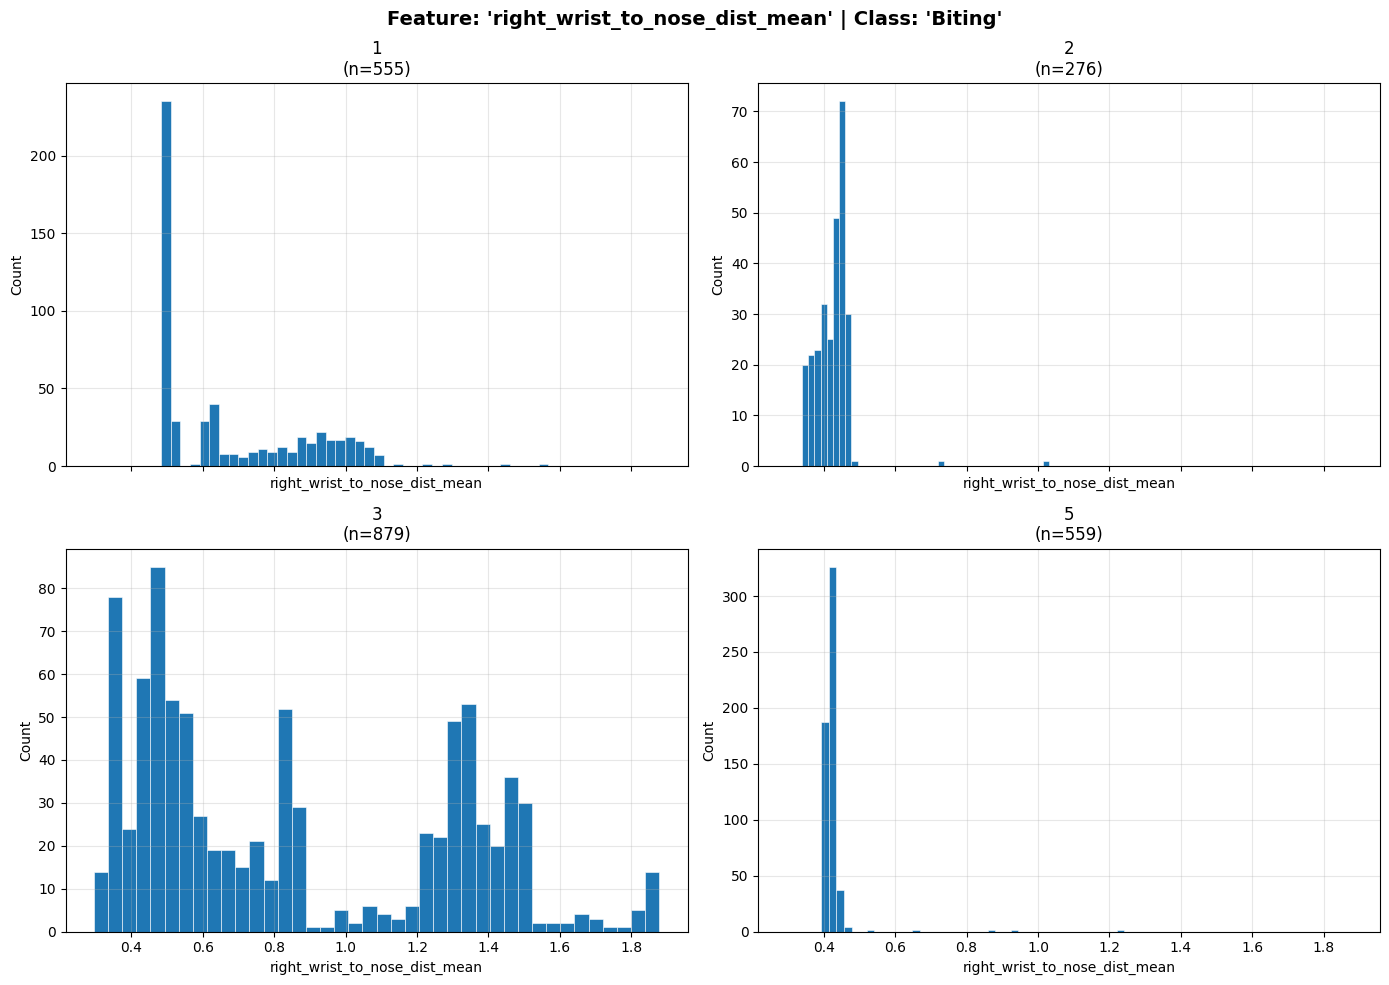

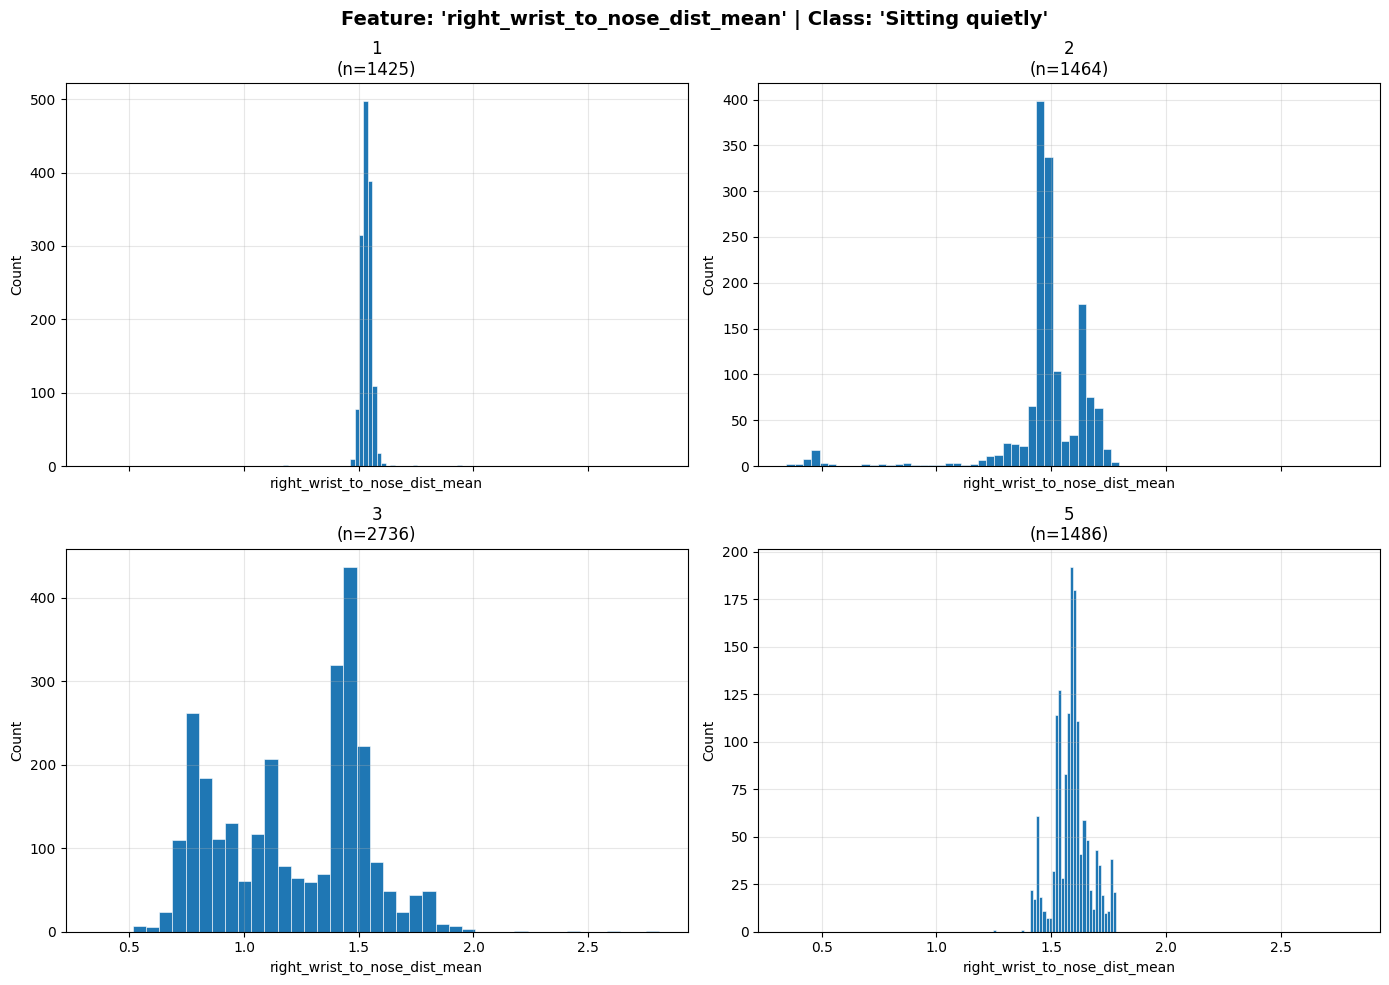

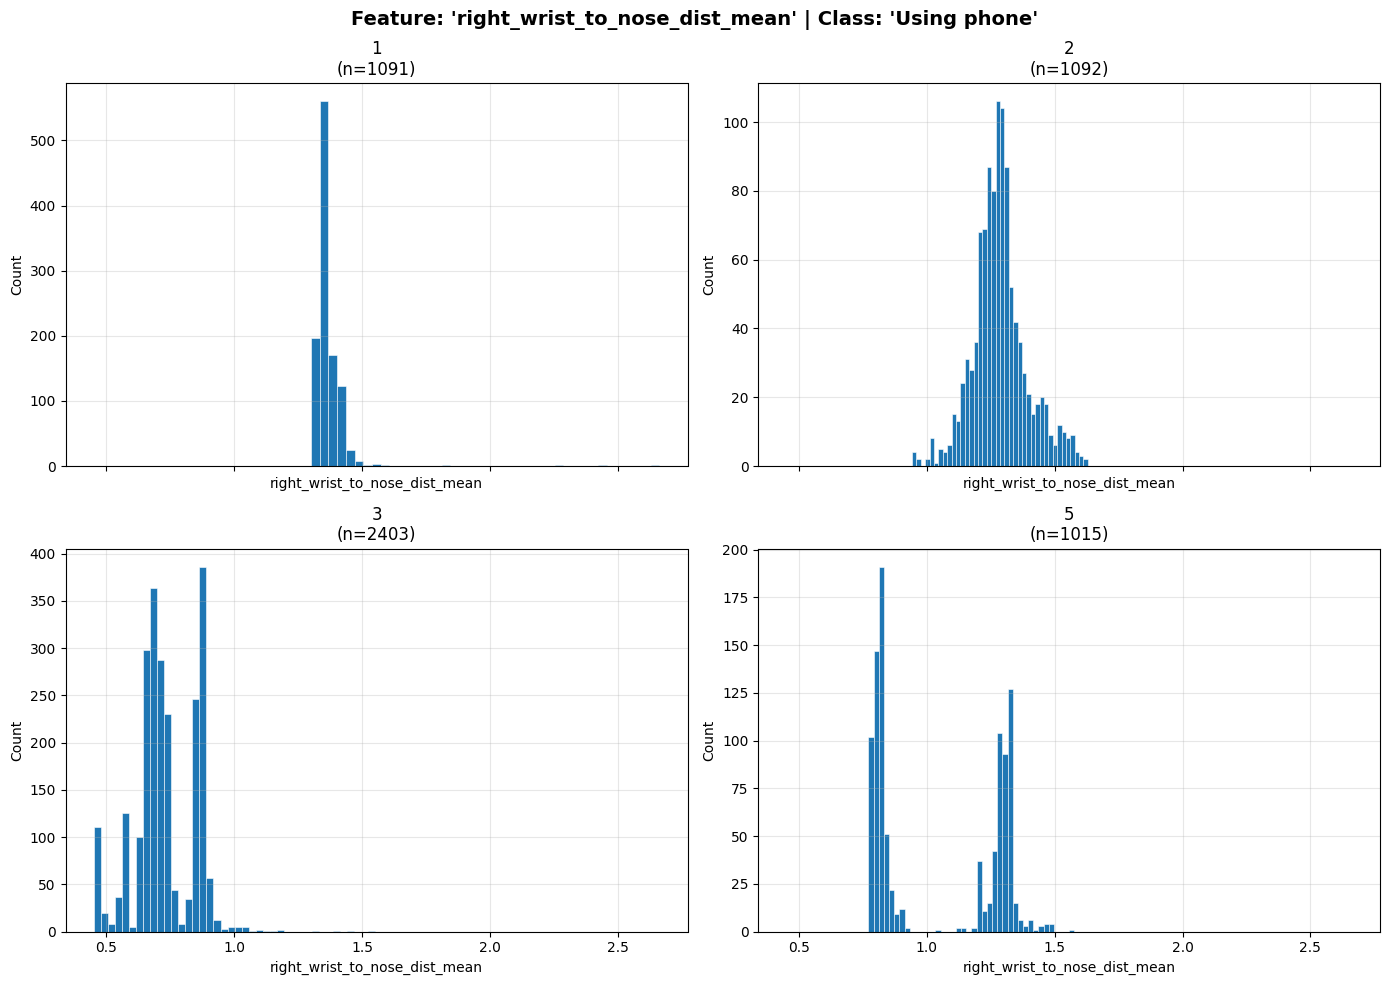

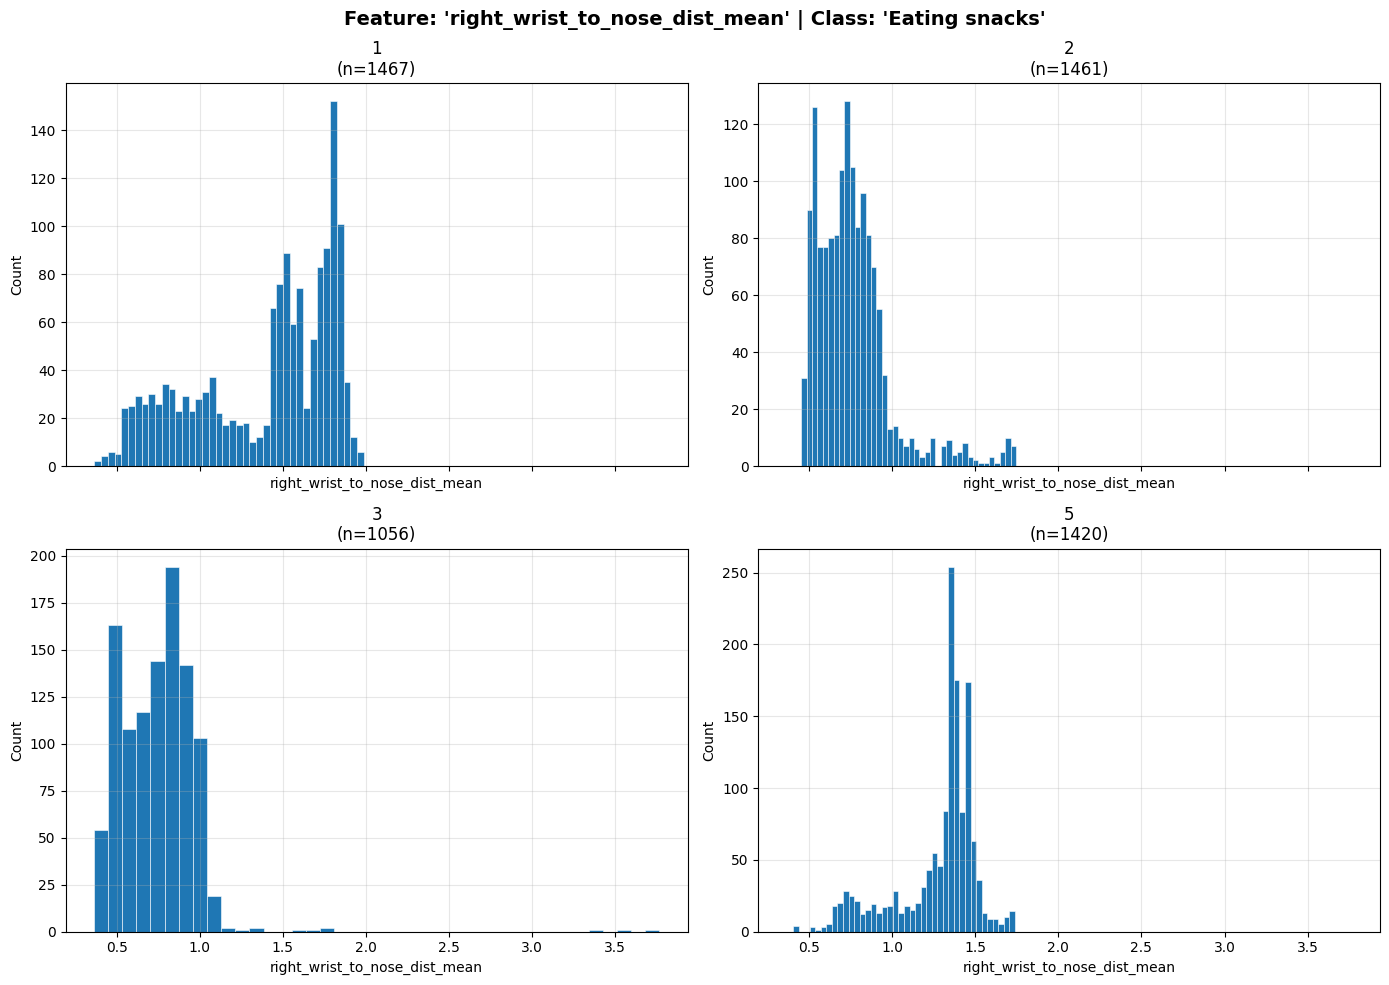

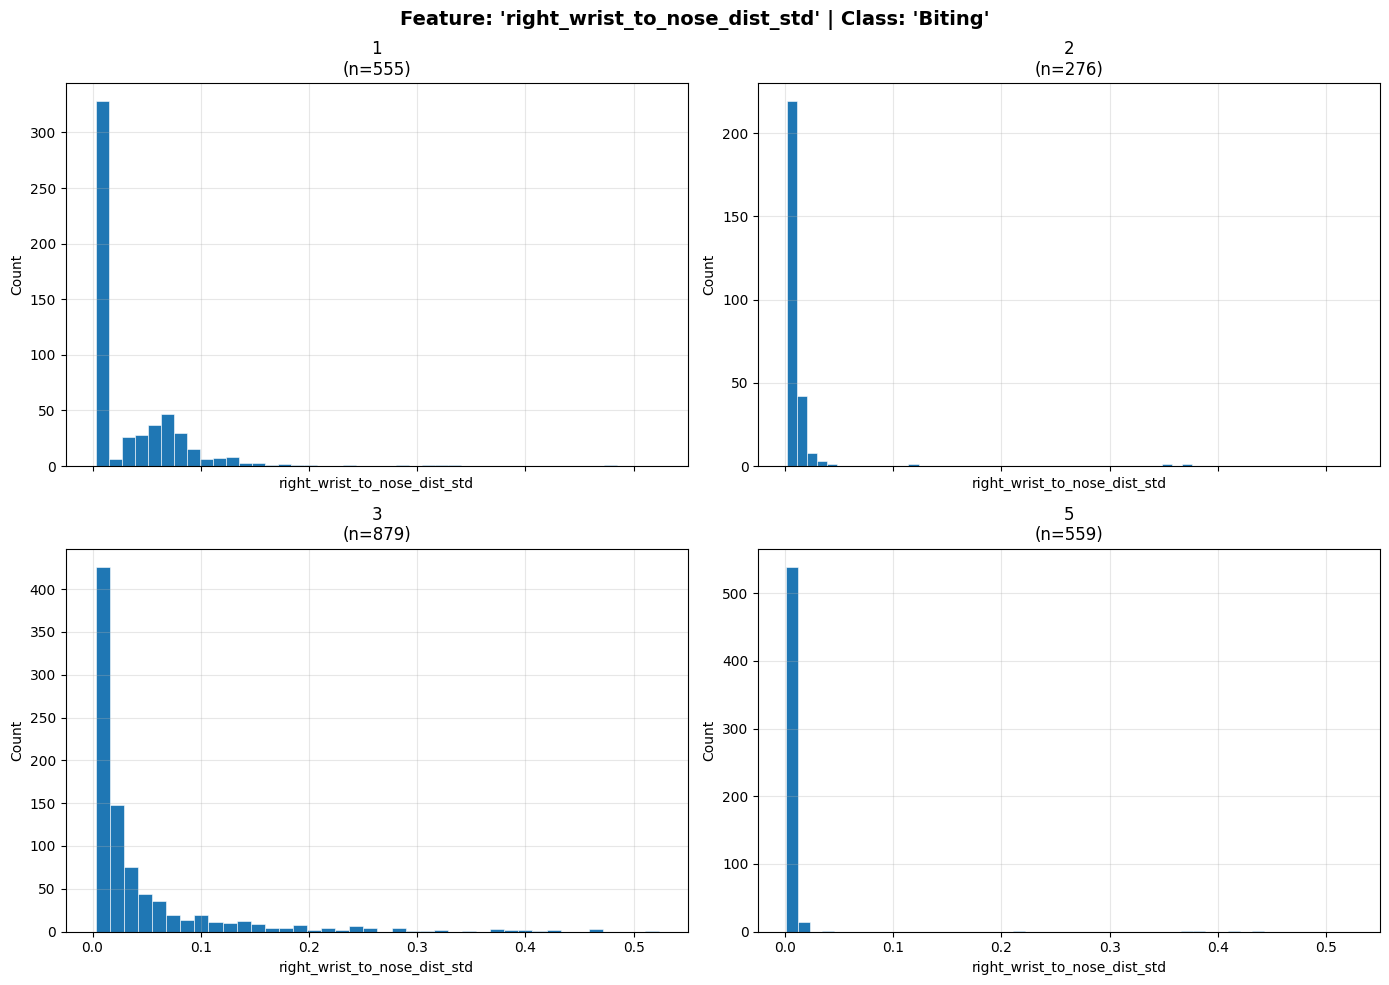

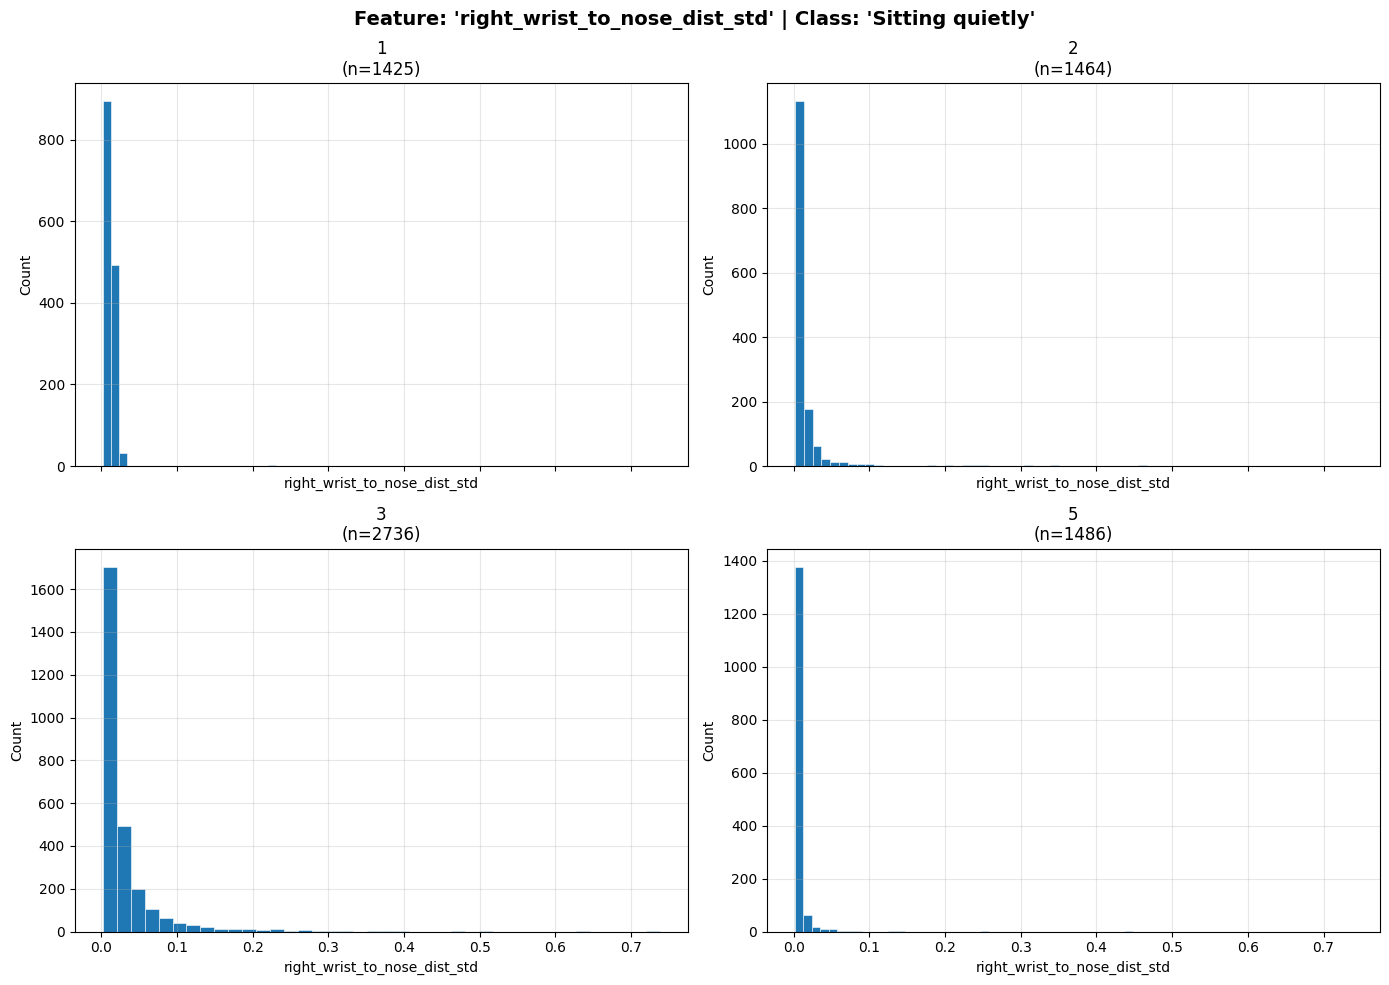

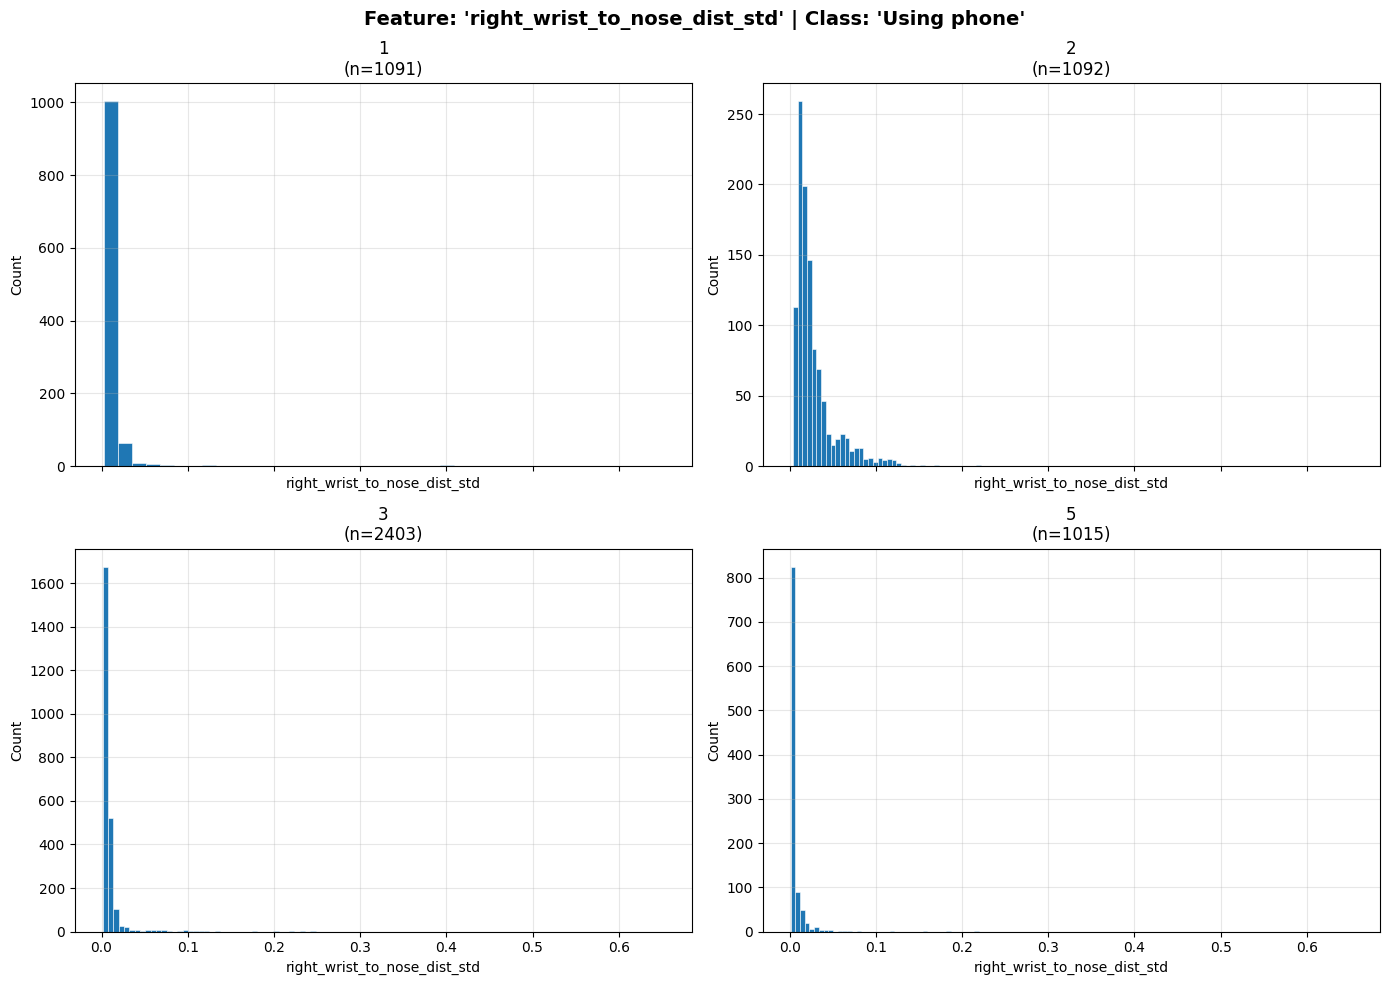

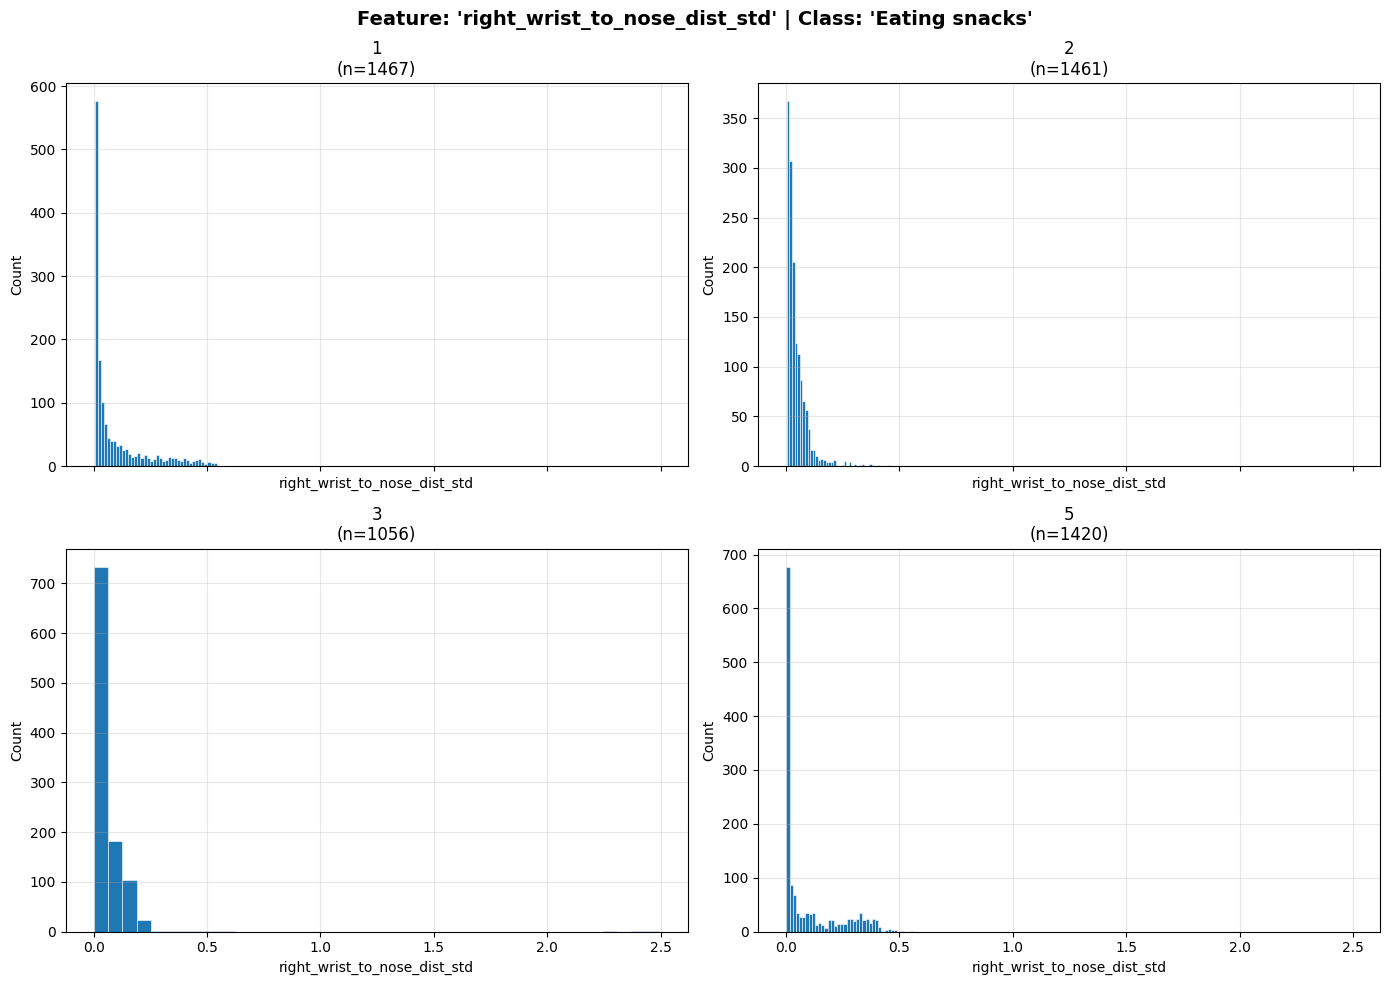

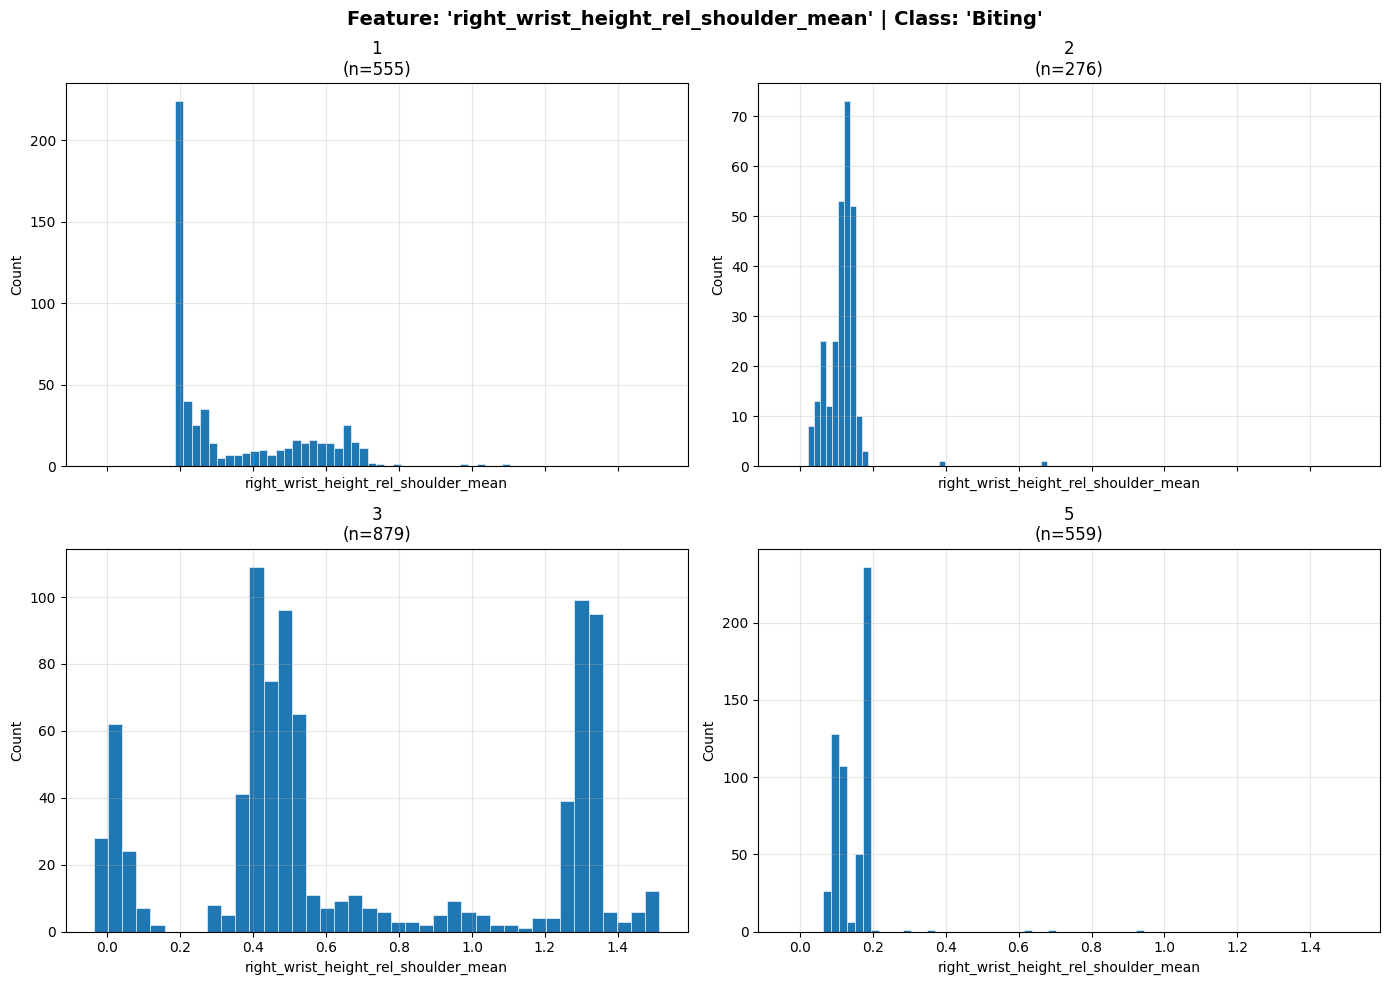

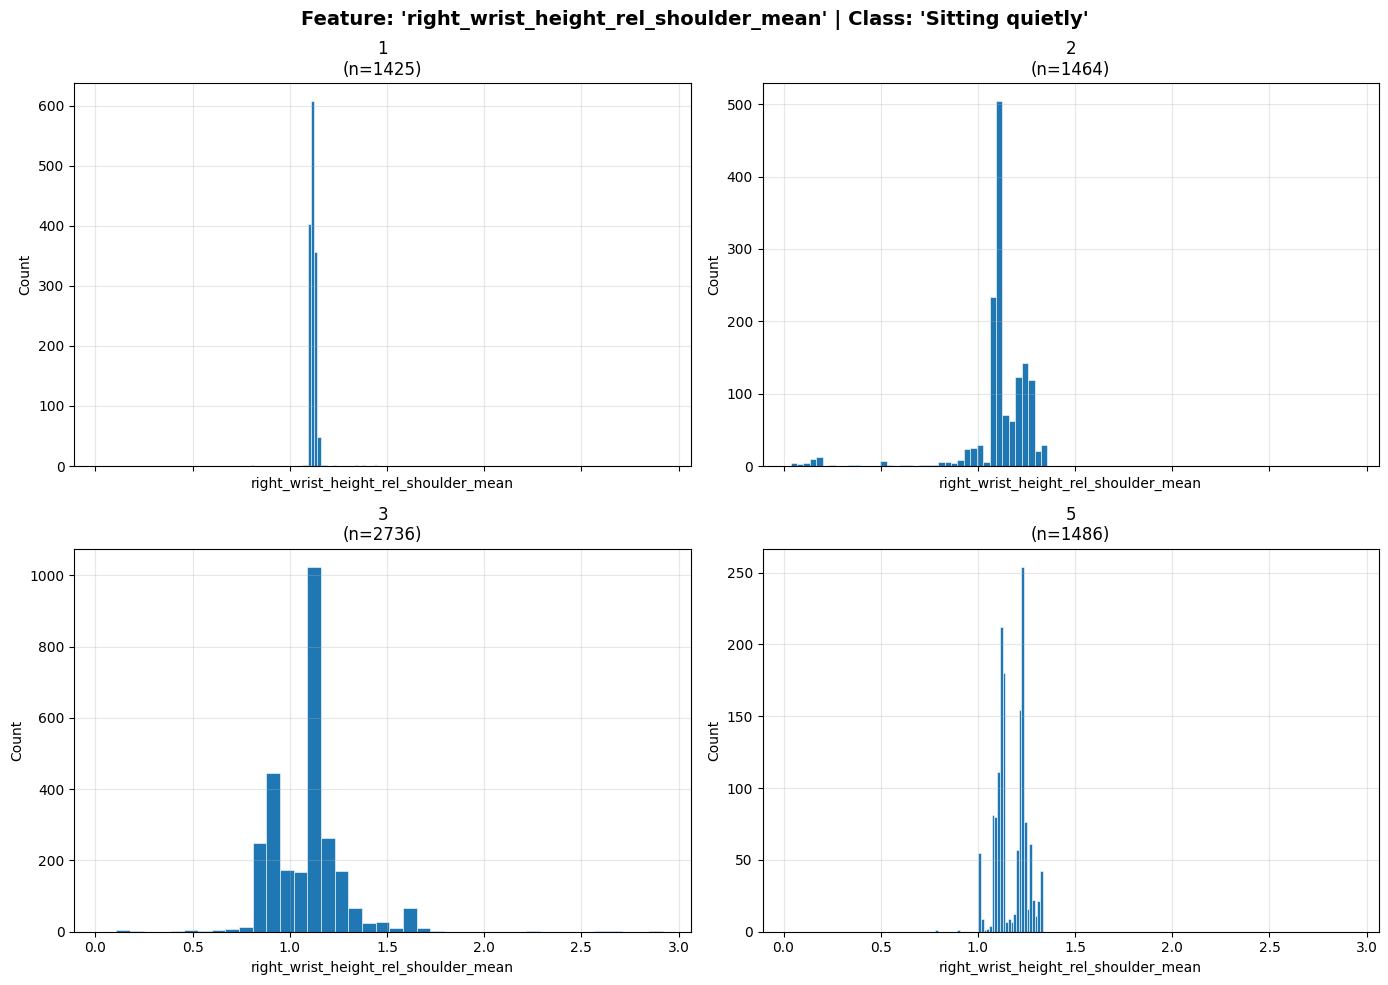

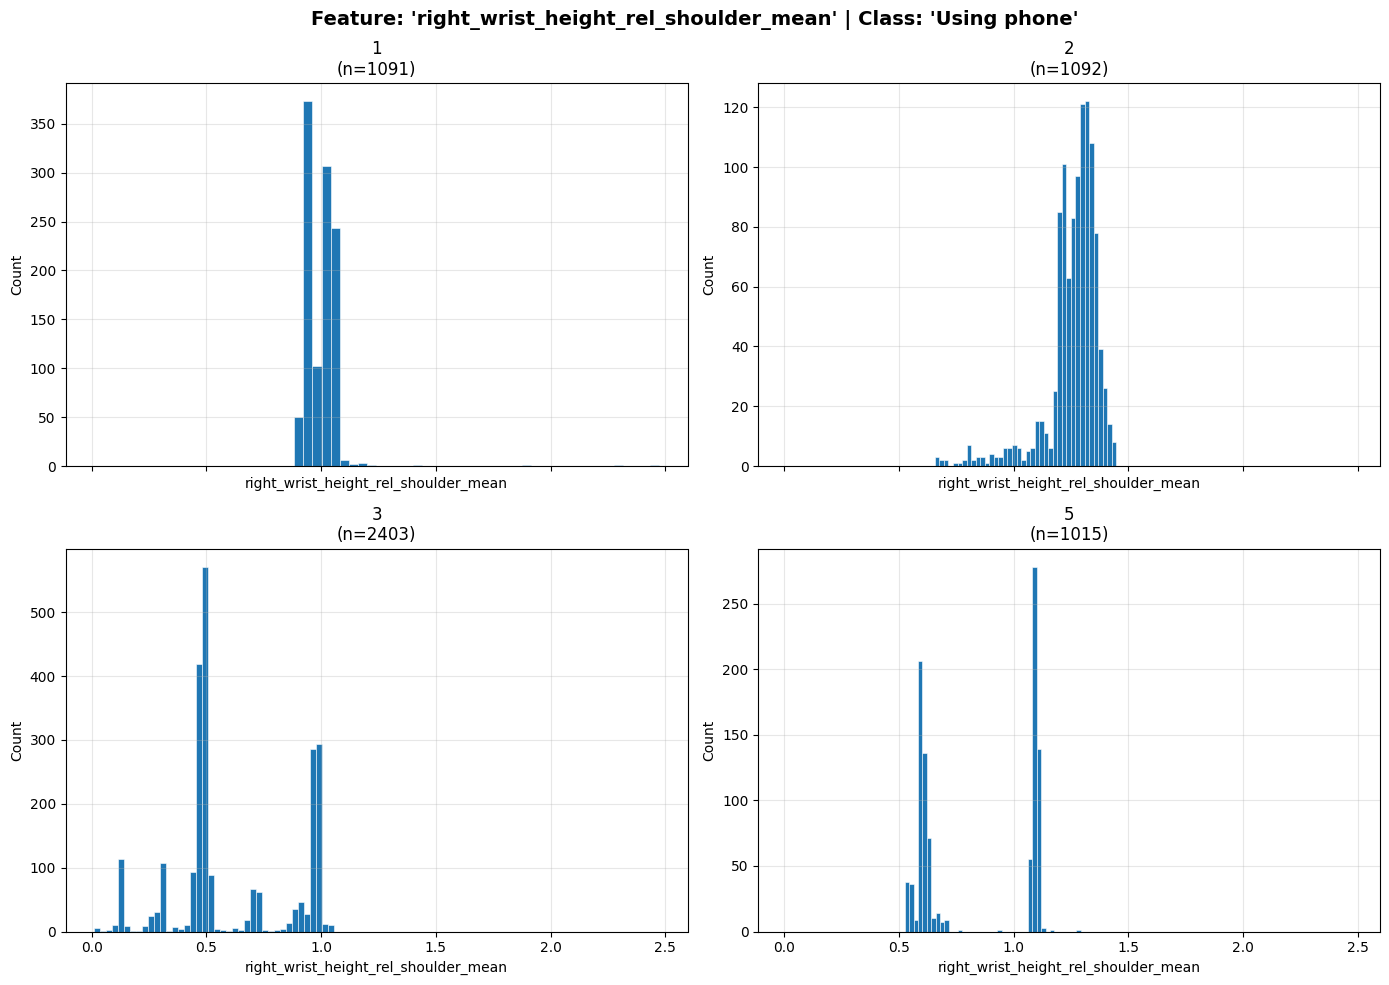

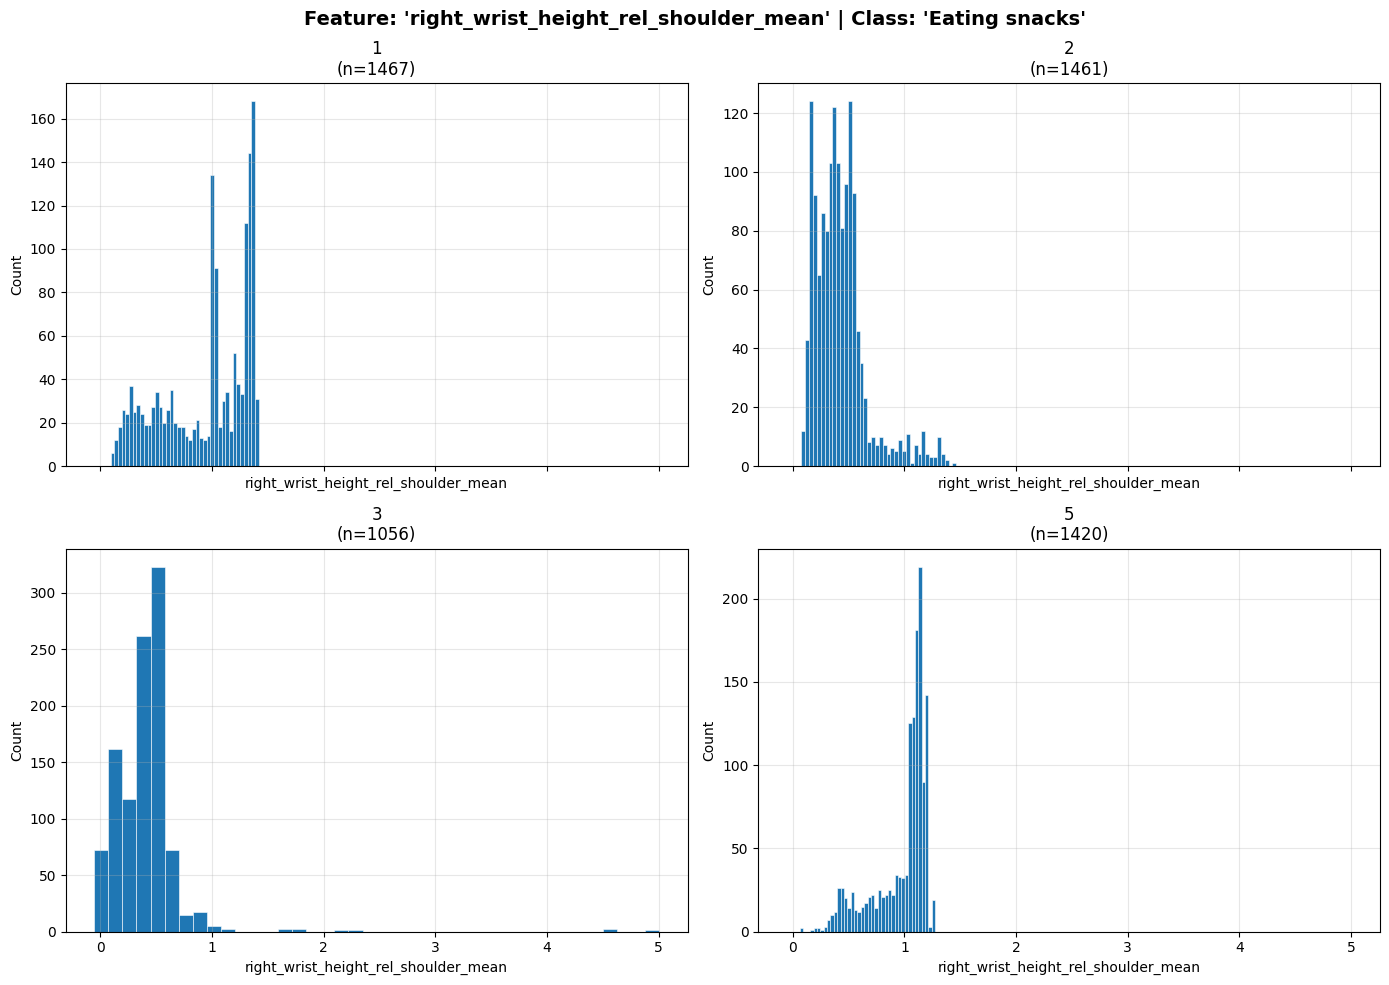

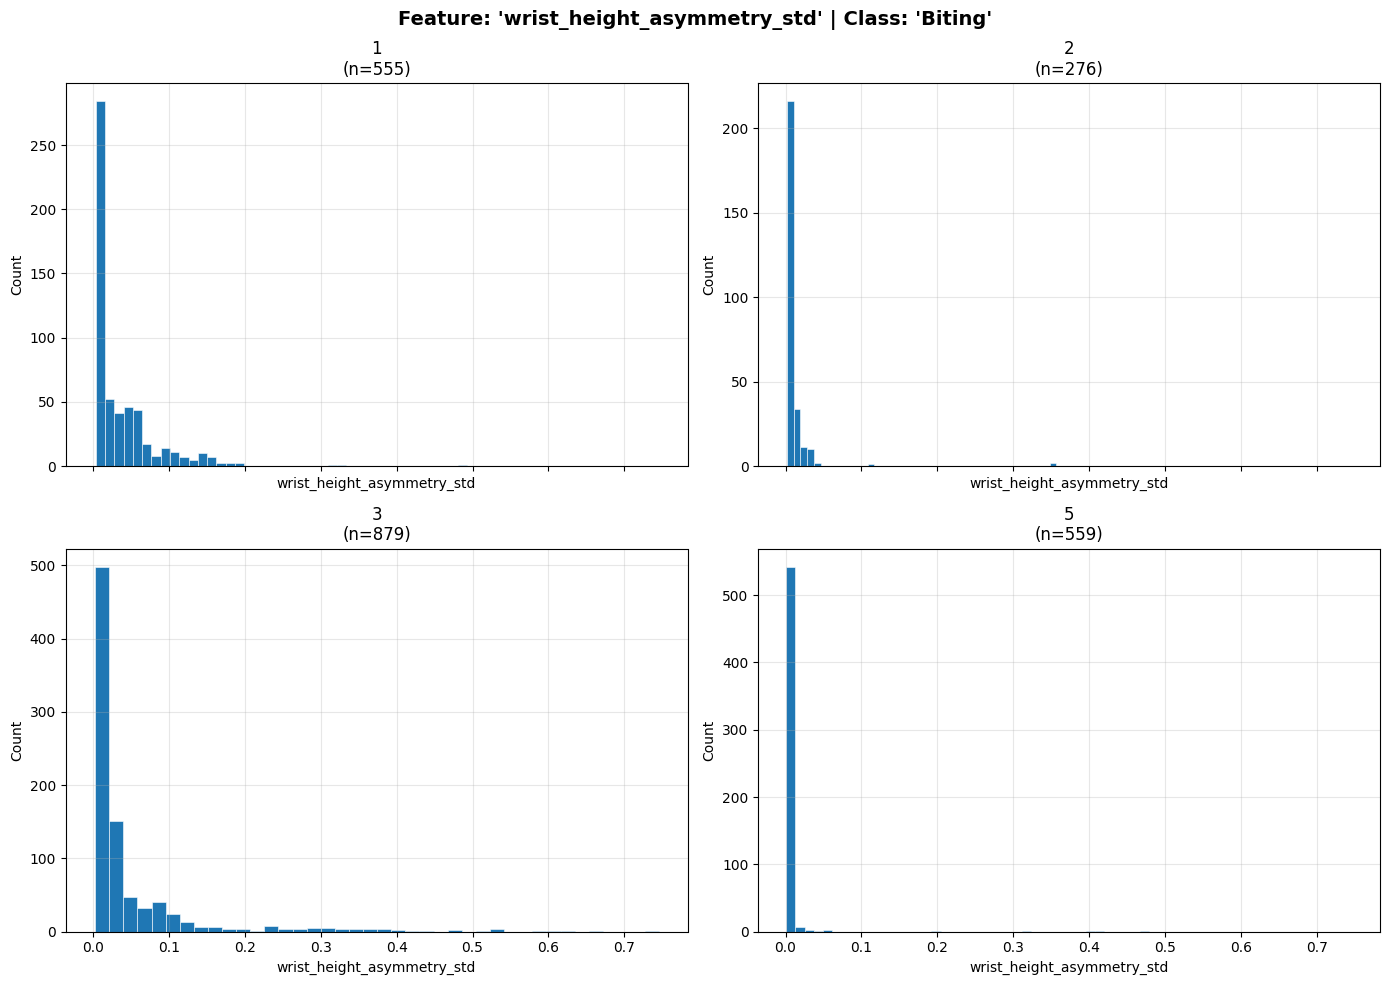

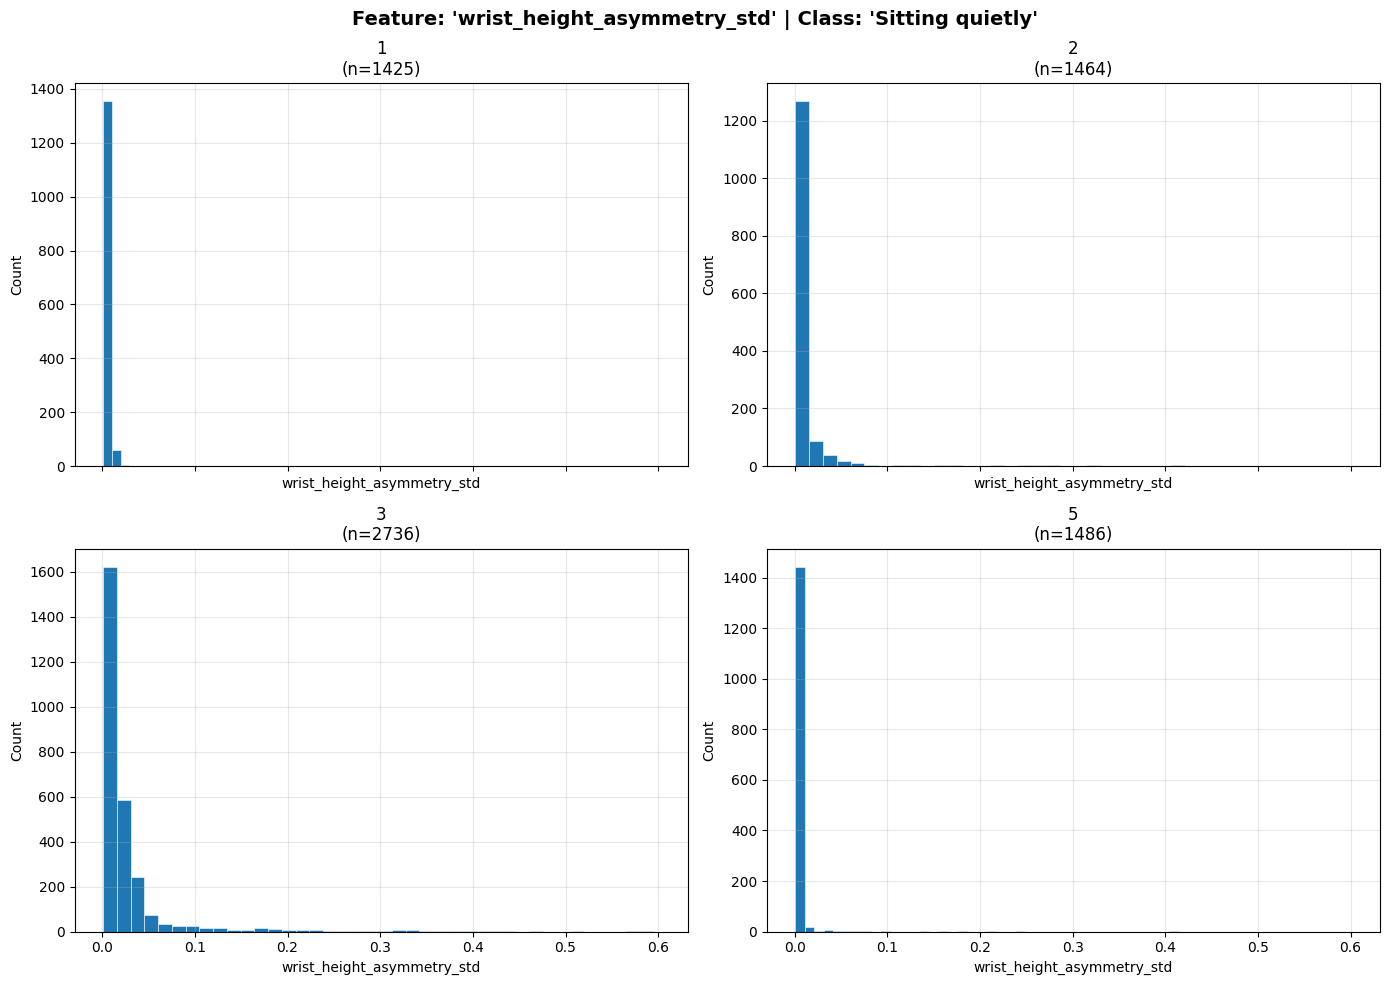

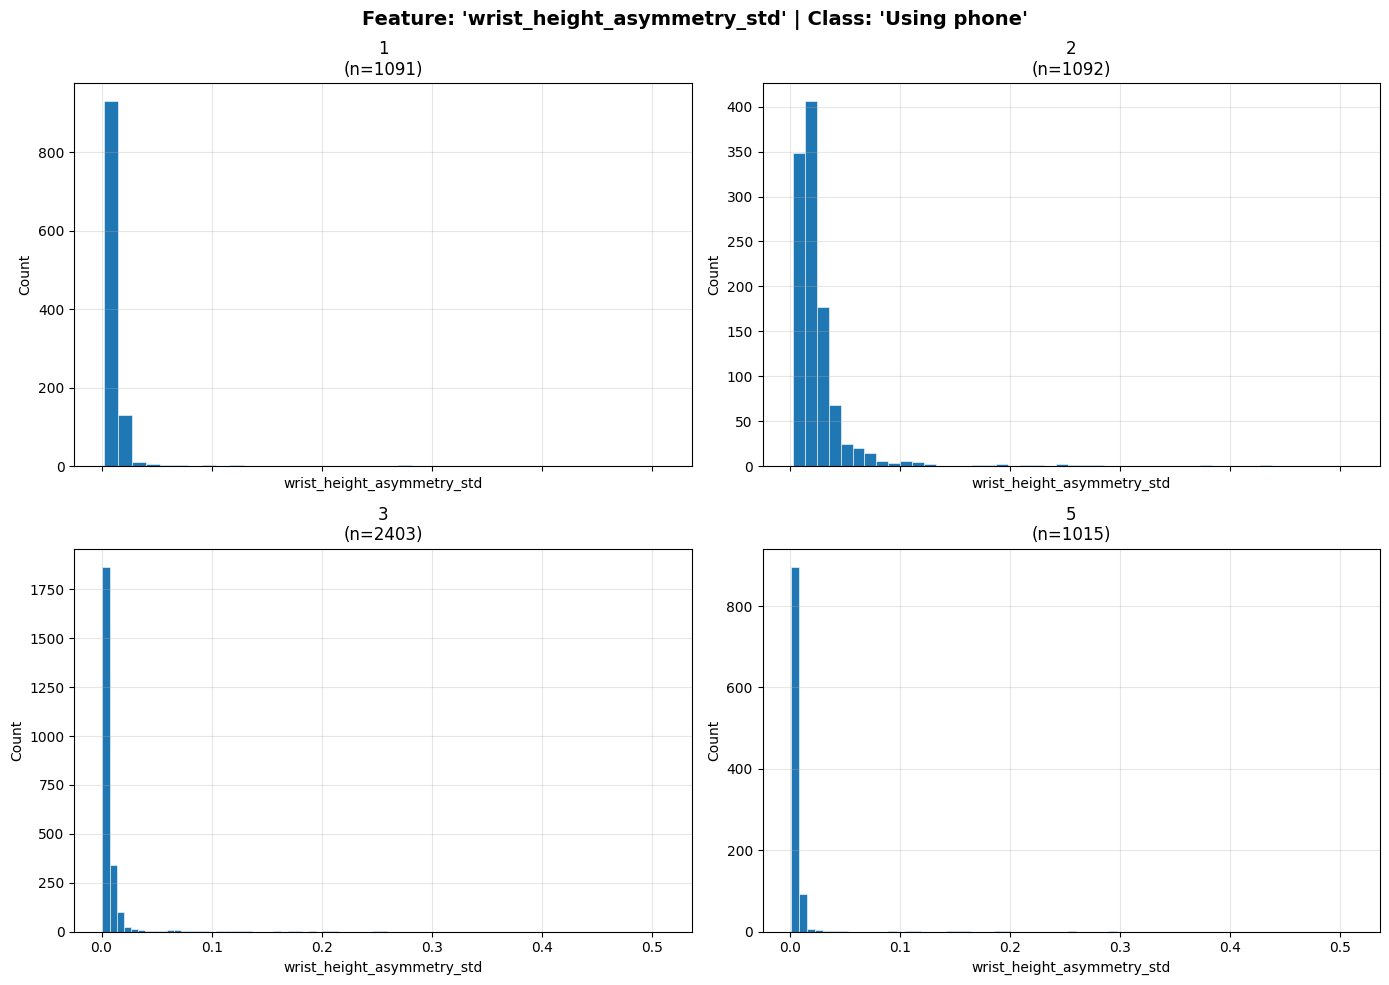

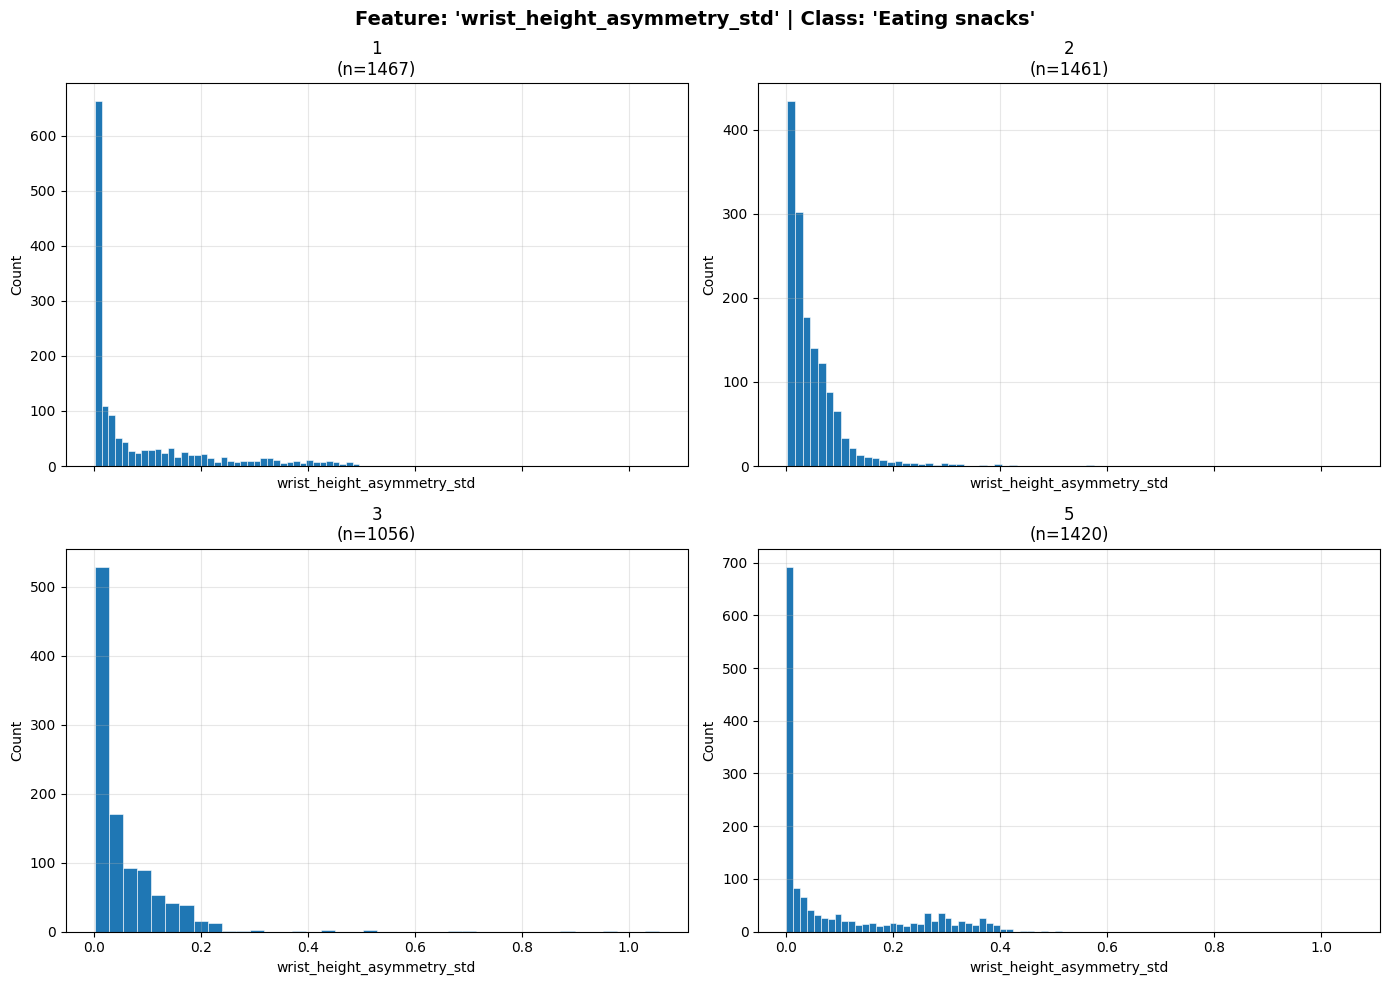

In [25]:
classes_of_interest = ['Biting', 'Sitting quietly', 'Using phone', 'Eating snacks']
features_of_interest = [
    'right_wrist_to_nose_dist_mean',
    'right_wrist_to_nose_dist_std',
    'right_wrist_height_rel_shoulder_mean',
    'wrist_height_asymmetry_std',
]

for feature in features_of_interest:
    for activity_class in classes_of_interest:
        plot_feature_class_across_subjects(
            all_subject_window_rom,
            feature=feature,
            activity_class=activity_class
        )

In [26]:
evaluate_random_forest(all_subject_window_rom, 12)

Train Subjects: ['1', '2', '3']
Test Subject : 5


NameError: name 'show_shape' is not defined

In [ ]:
evaluate_random_forest(all_subject_window_rom, 15)

In [20]:
evaluate_random_forest(all_subject_window_rom, 16)

NameError: name 'all_subject_window_rom' is not defined

In [32]:
# LOFO summary
fold_result = evaluate_random_forest_loso(all_subject_window_rom)


────────────────────────────────────────────────────
  Fold — Test Subject: 1  |  Train: ['2', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.46      0.09      0.15
  Biting                      0.00      0.00      0.00
  Eating snacks               0.20      0.40      0.27
  Head banging                0.97      0.28      0.44
  Sitting quietly             0.10      0.07      0.08
  Throwing things             0.39      0.62      0.48
  Using phone                 0.00      0.00      0.00
  Walking                     0.59      0.99      0.74

  Macro F1: 0.269

────────────────────────────────────────────────────
  Fold — Test Subject: 2  |  Train: ['1', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  A